In [169]:
# set auto-reload of the notebook
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [170]:
import cns
import cns.data_utils as cdu
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 10)
# set color_map to tab10
color_map = plt.cm.get_cmap('tab10').colors[:10]
plt.rcParams.update({'font.size': 12})

C:\Users\adams\AppData\Local\Temp\ipykernel_45204\1427791538.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10').colors[:10]


In [171]:
samples_df, cns_df = cdu.main_load("250KB")

In [172]:
cns_df = cns.group_samples(cns.only_aut(cns.add_total_cn(cns.select_cns_by_type(cns_df, samples_df, "LUSC"))))
cns_df["sample_id"] = "mean LUSC CN"

Norm factor: 0.00384306715766873


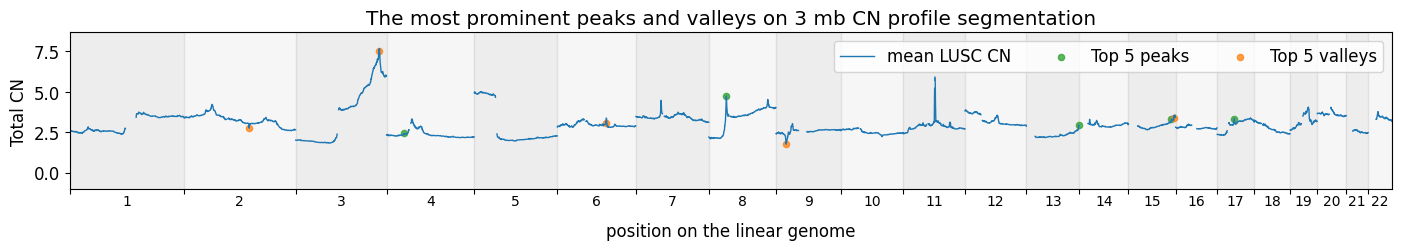

In [173]:
cns_df["score"] = cns.calc_angles(cns_df, "total_cn", 7)

feature = "score"
val_count = 5
sorted_pos = np.argsort(cns_df[feature])
# indices of top 5 values
top_vals = sorted_pos[:val_count]
bot_vals = sorted_pos[-val_count:]

fig, ax = cns.fig_lines(cns_df, cn_columns="total_cn", colors=color_map[0])
cns_df = cns.add_cum_mid(cns_df)
fig.set_size_inches(14, 2)

ax.scatter(cns_df["cum_mid"].iloc[bot_vals], cns_df["total_cn"].iloc[bot_vals], color=color_map[2], alpha=0.75, s=20, label="Top 5 peaks")
ax.scatter(cns_df["cum_mid"].iloc[top_vals], cns_df["total_cn"].iloc[top_vals], color=color_map[1], alpha=0.75, s=20, label="Top 5 valleys")

plt.title("The most prominent peaks and valleys on 3 mb CN profile segmentation")
plt.ylabel("Total CN")

# legend with 3 columns
ax.legend(loc="upper right", ncol=3)

cdu.save_cns_fig("3MB_cns_peaks_valleys")

In [174]:
segs = cdu.load_COSMIC()

In [175]:
scores_df = cns.mean_value_per_seg(cns_df, segs, "score").merge(cns.mean_value_per_seg(cns_df, segs, "total_cn"), on=["chrom", "start", "end", "name"])
scores_df["abs_score"] = scores_df["score"].abs()
scores_df["cum_mid"] = cns.calc_cum_mid(scores_df)
scores_df = scores_df.sort_values("abs_score", ascending=False)
scores_df.head(10)

,chrom,start,end,name,score,total_cn,abs_score,cum_mid
621,chr8,38268655,38326352,FGFR1,178.075238,4.731187,178.075238,1431093193
279,chr17,37844166,37886679,ERBB2,176.145468,3.327258,176.145468,2538037286
563,chr6,106534194,106557814,PRDM1,-172.792943,3.084155,172.792943,1169087964
656,chr9,21967750,21995300,CDKN2A,-172.147409,1.749367,172.147409,1561141237
104,chr11,44117098,44266979,EXT2,169.365662,3.046000,169.365662,1860099928
557,chr6,41902670,42018095,CCND3,169.045913,3.072918,169.045913,1104502342
545,chr6,26031816,26032288,HIST1H3B,-165.706860,2.839836,165.706860,1088574012
19,chr1,40361097,40367928,MYCL,164.303695,2.823375,164.303695,40364512
500,chr4,54875955,54930857,CHIC2,162.735463,3.295680,162.735463,745375830
229,chr15,90626276,90645736,IDH2,162.501671,3.120201,162.501671,2397921725


Text(0.5, 1.0, 'Top 2 genes with highest absolute change score on chr3 in LUSC')

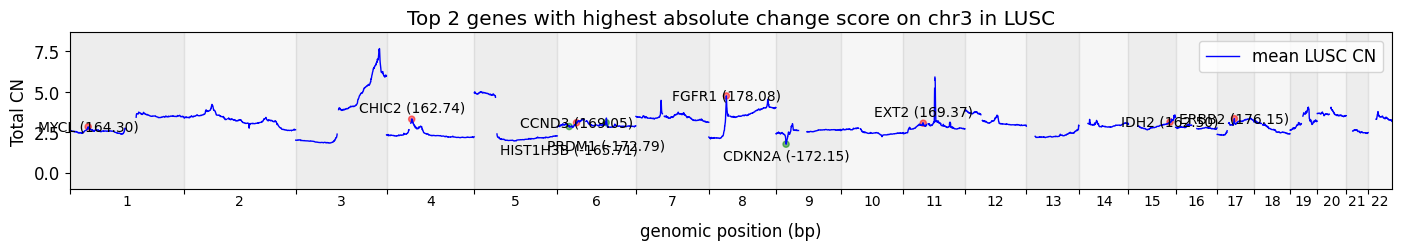

In [176]:
fig, ax = cns.fig_lines(cns_df, cn_columns="total_cn")

# scatter plot of top 5 values in scores_df, use red is score is positive, blue if negative
top_count = 10
top_genes = scores_df.head(top_count)
colors = ["red" if score > 0 else "green" for score in top_genes["score"]]
ax.scatter(top_genes["cum_mid"], top_genes["total_cn"], color=colors, alpha=0.5, s=20)

for i, row in top_genes.iterrows():
	offset = .7 * (-1 if row["score"] > 0 else 1) + (i % 2 * 0.7)
	ax.text(row["cum_mid"], row["total_cn"] - offset, f'{row["name"]} ({row["score"]:.2f})', fontsize=10, ha="center", va="center")


fig.set_size_inches(14, 2)
ax.set_ylabel("Total CN")
ax.set_xlabel("genomic position (bp)")
ax.set_title("Top 2 genes with highest absolute change score on chr3 in LUSC")